In [97]:
import os
import numpy as np
import pandas as pd
import xarray as xr

import geopandas as gpd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

In [2]:
product, time_reso = 'CMORPH', '3h'

In [99]:
lon_min, lon_max, lat_min, lat_max, area, toll = 6.5, 19, 36.5, 48, 'ITALY', 0.002

In [3]:
COMPUTERNAME = os.environ['COMPUTERNAME']
print(f'Computer: {COMPUTERNAME}')

if COMPUTERNAME == 'BR_DELL':
    dir_font = os.path.join('/','run')
else:
    dir_font = os.path.join('/')

dir_base = os.path.join('/','media','arturo','T9','Data','Italy')

veneto_dir = os.path.join(dir_font,'media','arturo','T9','Data','shapes','Europa','Italy')

obs_base = os.path.join(dir_font,'media','arturo','T9','Data','Italy','Rain_Gauges_QC')

dir_cal = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC','CAL_VAL', 'Calibration')
dir_val = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC','CAL_VAL', 'Validation')

Computer: UNIPD_DELL


In [4]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

In [16]:
list_remove = [
            'IT-820_1424_FTS_1440_QCv4.csv', 'IT-250_602781_FTS_1440_QCv4.csv', 
            'IT-250_602779_FTS_1440_QCv4.csv', 'IT-780_2370_FTS_1440_QCv4.csv', 
            'IT-750_450_FTS_1440_QCv4.csv', 'IT-520_TOS11000099_FTS_1440_QCv4.csv',
            'IT-520_TOS11000080_FTS_1440_QCv4.csv', 'IT-520_TOS11000072_FTS_1440_QCv4.csv',
            'IT-520_TOS11000060_FTS_1440_QCv4.csv', 'IT-520_TOS11000025_FTS_1440_QCv4.csv',
            'IT-520_TOS09001200_FTS_1440_QCv4.csv', 'IT-520_TOS02000237_FTS_1440_QCv4.csv',
            'IT-230_1200_FTS_1440_QCv4.csv'
            ]

METADATA = pd.read_csv(os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy.csv'))
METADATA["Lat"] = np.round(METADATA["Lat"], 6)
METADATA["Lon"] = np.round(METADATA["Lon"], 6)

METADATA = METADATA[~METADATA['File'].isin(list_remove)].reset_index(drop=True)

In [71]:
data_dir = os.path.join(dir_base, 'Satellite','5_DOWN', f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
ds = xr.open_dataset(data_dir)

lat_grid = ds['lat'].values
lon_grid = ds['lon'].values
lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)

In [18]:
for iso in METADATA['ISO'].unique():
    METADATA_VAL = METADATA[METADATA['ISO'] == iso]
    
    ISO = METADATA_VAL['ISO'].values[0]

df = pd.read_csv(os.path.join(obs_base,'Weibull','1dy',ISO,METADATA_VAL['File'].values[0]))

lat = METADATA_VAL['Lat']
lon = METADATA_VAL['Lon']

In [19]:
def find_nearest_grid_point(lat, lon, lat_grid, lon_grid):
    lat_idx = np.abs(lat_grid - lat).argmin()
    lon_idx = np.abs(lon_grid - lon).argmin()
    return lat_idx, lon_idx

In [20]:
metadata = METADATA.copy()

metadata[['lat_idx','lon_idx']] = metadata.apply(
    lambda row: find_nearest_grid_point(
        row['Lat'], row['Lon'],
        lat_grid, lon_grid
    ),
    axis=1,
    result_type='expand'
)

In [79]:
all_data = []

for nn in range(len(metadata)):
    name = metadata['File'].values[nn]
    ISO = metadata['ISO'].values[nn]
    df_station = pd.read_csv(os.path.join(obs_base,'Weibull','1dy',ISO,name))

    df_station['lat_idx'] = metadata['lat_idx']
    df_station['lon_idx'] = metadata['lon_idx']

    all_data.append(df_station)

df_all = pd.concat(all_data, ignore_index=True)

In [122]:
metadata

,File,ISO,Region,Code,Name,Elevatn,Or_EPSG,CRS_E,CRS_N,Lat,...,SameRegion_H_NOQC,Rho_H_QC,AI_H_QC,Overlap_H_QC,TargetName_H_QC,TargetDist_H_QC,TargetElev_H_QC,SameRegion_H_QC,lat_idx,lon_idx
0,IT-210_PIE-001030-900_FTS_1440_QCv4.csv,IT-210,Piedmont,PIE-001030-900,BORGOFRANCODIVREA,337.0,32632,410005.0,5040731.0,45.514302,...,1.0,0.647599,0.614767,36.363014,IT-210_PIE-001151-900_FTS_0060_QCv4.csv,6857.364241,633.857117,1.0,36,5
1,IT-210_PIE-001097-900_FTS_1440_QCv4.csv,IT-210,Piedmont,PIE-001097-900,CUMIANA,327.0,32632,373092.0,4980177.0,44.963696,...,1.0,0.405230,0.501574,36.621918,IT-210_PIE-001139-900_FTS_0060_QCv4.csv,20507.220598,474.270203,1.0,33,3
2,IT-210_PIE-001128-900_FTS_1440_QCv4.csv,IT-210,Piedmont,PIE-001128-900,LANZO,580.0,32632,381803.0,5016138.0,45.288798,...,1.0,0.460615,0.485786,35.001027,IT-210_PIE-001134-900_FTS_0060_QCv4.csv,17953.296525,1129.634033,1.0,35,3
3,IT-210_PIE-001134-900_FTS_1440_QCv4.csv,IT-210,Piedmont,PIE-001134-900,BERTODASCO,1120.0,32632,375605.0,5032982.0,45.439288,...,0.0,0.485623,0.444079,10.888470,IT-230_1160_FTS_0060_QCv4.csv,17041.227682,2203.382080,0.0,35,3
4,IT-210_PIE-001139-900_FTS_1440_QCv4.csv,IT-210,Piedmont,PIE-001139-900,LUSERNASGIOVANNI,475.0,32632,360924.0,4963661.0,44.812810,...,1.0,0.405230,0.501574,36.621918,IT-210_PIE-001097-900_FTS_0060_QCv4.csv,20507.220598,322.049591,1.0,33,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,IT-880_38306_FTS_1440_QCv4.csv,IT-880,Sardinia,38306,MANNU A MONTI PRANU METEO,47.0,32632,464472.0,4327122.0,39.092502,...,1.0,0.546774,0.537380,7.075114,IT-880_30947_FTS_0060_QCv4.csv,11267.567247,164.087006,1.0,10,8
2926,IT-880_57870_FTS_1440_QCv4.csv,IT-880,Sardinia,57870,DIGA PRANU ANTONI,47.0,32632,486746.0,4427892.0,40.001110,...,1.0,0.912671,0.808337,6.719863,IT-880_38196_FTS_0060_QCv4.csv,1766.464122,122.048599,1.0,14,9
2927,IT-880_57964_FTS_1440_QCv4.csv,IT-880,Sardinia,57964,COGHINAS A VIDDALBA,8.0,32632,490479.0,4528742.0,40.909726,...,1.0,0.914040,0.799138,6.650571,IT-880_57969_FTS_0060_QCv4.csv,1475.028961,34.001900,1.0,17,9
2928,IT-880_57969_FTS_1440_QCv4.csv,IT-880,Sardinia,57969,RIU BADDE CAPRILE A VIDDALBA,38.0,32632,491486.0,4529820.0,40.919448,...,1.0,0.914040,0.799138,6.650571,IT-880_57964_FTS_0060_QCv4.csv,1475.028961,14.144780,1.0,17,9


In [123]:
df_all

,Year,N,C,W,NaN,lat_idx,lon_idx
0,1989,66.0,10.095218,0.783110,0.0,36,5
1,1990,73.0,8.580549,0.849747,0.0,33,3
2,1991,63.0,9.953785,0.737089,0.0,35,3
3,1992,77.0,11.414905,0.911335,0.0,35,3
4,1993,94.0,10.430489,0.758110,0.0,33,2
...,...,...,...,...,...,...,...
56154,2019,58.0,5.958613,0.834282,0.0,35,3
56155,2020,48.0,7.265827,0.609843,0.0,35,3
56156,2021,62.0,6.416977,0.652689,0.0,33,2
56157,2022,38.0,7.581254,0.792616,0.0,35,5


In [81]:
grouped = (
    df_all
    .groupby(['Year','lat_idx','lon_idx'])['N']
    .mean()
    .reset_index()
)

In [82]:
year_index = np.arange(
    df_all['Year'].min(),
    df_all['Year'].max() + 1
)

In [84]:
N_array = np.full((len(year_index), len(lat_grid), len(lon_grid)),np.nan)

In [85]:
year_lookup = {year:i for i, year in enumerate(year_index)}

In [86]:
for _, row in grouped.iterrows():
    y_idx = year_lookup[row['Year']]
    N_array[y_idx, int(row['lat_idx']), int(row['lon_idx'])] = row['N']

In [87]:
wetdays_year_grid = xr.DataArray(
    N_array,
    coords=[year_index, lat_grid, lon_grid],
    dims=["year","lat","lon"],
    name="N_wetdays"
)

In [93]:
WD_mean = np.nanmean(wetdays_year_grid.values,axis=0)
WD_sum = np.nansum(wetdays_year_grid.values,axis=0)

/tmp/ipykernel_14072/3904397055.py:1: RuntimeWarning: Mean of empty slice
  WD_mean = np.nanmean(wetdays_year_grid.values,axis=0)


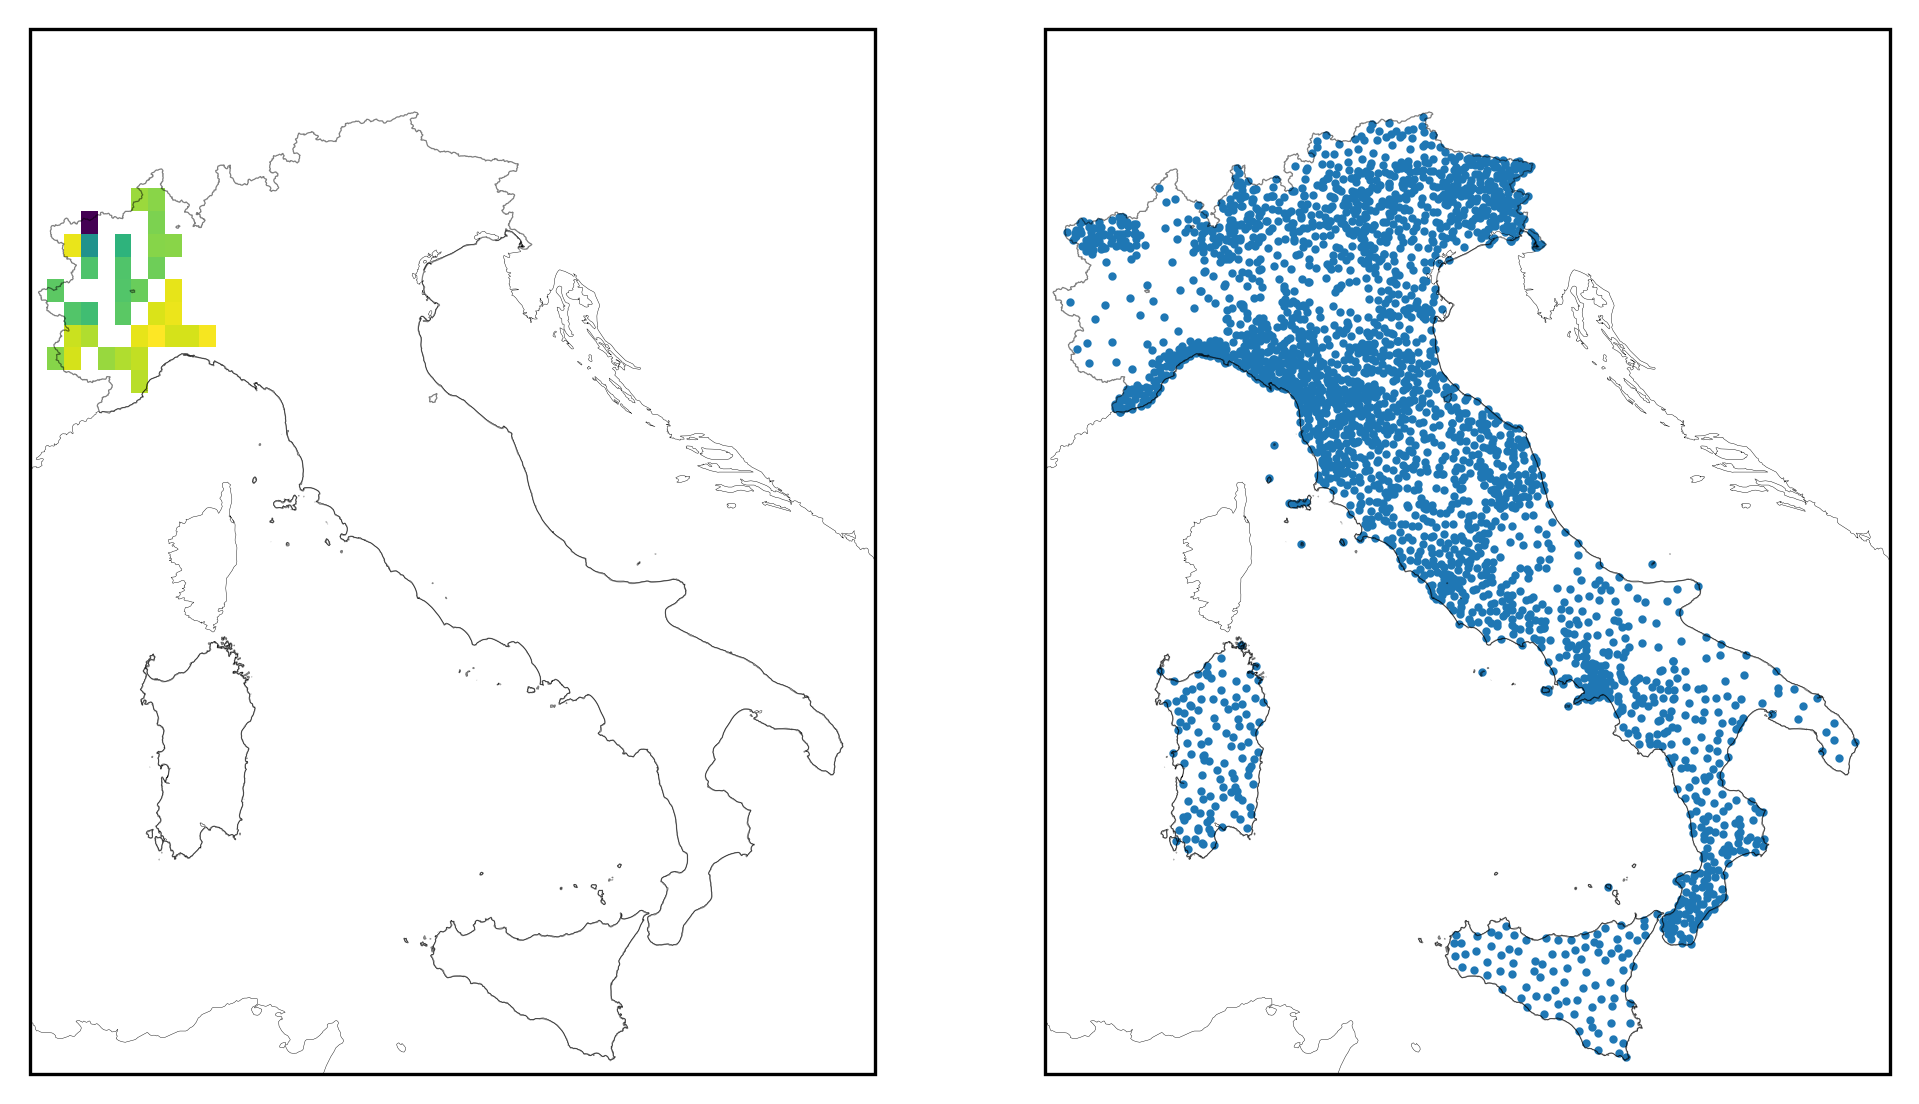

In [121]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(8,5),dpi=300)
gs = gridspec.GridSpec(1,2)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d, lat2d, WD_mean)
# cbar = plt.colorbar(a1, fraction=0.055)
# cbar.ax.tick_params(labelsize=8)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
ax1.scatter(metadata['Lon'],metadata['Lat'],s=1)